# Credit Default — Modeling

Binary classification: predict whether a client defaults next month. Logistic Regression vs. HistGradientBoosting, evaluated on a held-out test set.

Data: `../data/credit_default_clean.csv` (30,000 rows), produced by the EDA notebook. All features are known at decision time; all outcomes are resolved. No timestamps exist, so out-of-time evaluation is not supported — this classifies a snapshot.

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
from preprocessing import FEATURE_COLUMNS, TARGET

df = pd.read_csv("../data/credit_default_clean.csv")
X = df[FEATURE_COLUMNS]
y = df[TARGET]
print(X.shape, "| default rate:", round(y.mean(), 4))

(30000, 23) | default rate: 0.2212


## Stratified train/test split

Stratification keeps the 22.1% default rate identical in train and test.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
print("train default rate:", round(y_train.mean(), 4),
      "| test default rate:", round(y_test.mean(), 4),
      "| test n:", len(y_test))

train default rate: 0.2212 | test default rate: 0.2212 | test n: 9000


## Baseline

Predicting "no default" for everyone scores the majority share. A model must beat this to show it learned anything.

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
base_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"majority-class baseline accuracy: {base_acc:.4f}")

majority-class baseline accuracy: 0.7788


## Candidate models

- Logistic Regression inside a `StandardScaler` pipeline (scaling fit on train only; convergence explicitly verified).
- HistGradientBoosting (no scaling needed for trees).

In [4]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
hgb = HistGradientBoostingClassifier(random_state=42)

logreg.fit(X_train, y_train)
hgb.fit(X_train, y_train)

n_iter = logreg.named_steps["logisticregression"].n_iter_.max()
print("logreg iterations used:", n_iter, "| converged:", n_iter < 1000)

logreg iterations used: 27 | converged: True


In [5]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                                   f1_score, roc_auc_score, confusion_matrix,
                                   classification_report)

def report(name, model):
    p = model.predict(X_test)
    pr = model.predict_proba(X_test)[:, 1]
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, p):.4f}")
    print(f"Precision: {precision_score(y_test, p):.4f}")
    print(f"Recall:    {recall_score(y_test, p):.4f}")
    print(f"F1:        {f1_score(y_test, p):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, pr):.4f}")
    print("Confusion matrix [tn, fp / fn, tp]:")
    print(confusion_matrix(y_test, p))
    print()

report("Logistic Regression", logreg)
report("HistGradientBoosting", hgb)
print(f"Majority-class baseline accuracy: {base_acc:.4f}")

--- Logistic Regression ---
Accuracy:  0.8079
Precision: 0.6932
Recall:    0.2361
F1:        0.3522
ROC-AUC:   0.7150
Confusion matrix [tn, fp / fn, tp]:
[[6801  208]
 [1521  470]]

--- HistGradientBoosting ---
Accuracy:  0.8178
Precision: 0.6620
Recall:    0.3601
F1:        0.4665
ROC-AUC:   0.7768
Confusion matrix [tn, fp / fn, tp]:
[[6643  366]
 [1274  717]]

Majority-class baseline accuracy: 0.7788


In [6]:
print(classification_report(y_test, hgb.predict(X_test), digits=3))

              precision    recall  f1-score   support

           0      0.839     0.948     0.890      7009
           1      0.662     0.360     0.466      1991

    accuracy                          0.818      9000
   macro avg      0.751     0.654     0.678      9000
weighted avg      0.800     0.818     0.796      9000



## Calibration check

A decision service needs probabilities it can trust, not just rankings. Brier score (lower is better) and the reliability curve show whether predicted probabilities match observed default rates.

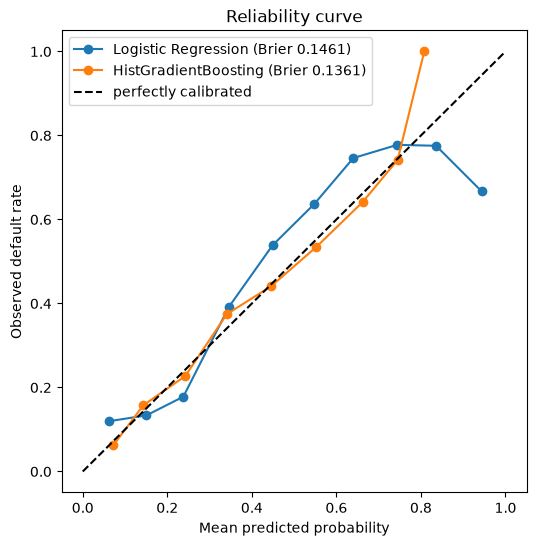

In [7]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(6, 6))
for name, model in [("Logistic Regression", logreg), ("HistGradientBoosting", hgb)]:
    pr = model.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, pr)
    frac_pos, mean_pred = calibration_curve(y_test, pr, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{name} (Brier {brier:.4f})")
ax.plot([0, 1], [0, 1], "k--", label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Reliability curve")
ax.legend()
plt.show()

## Threshold analysis

The default 0.5 threshold is arbitrary. Below: precision/recall at 0.3, 0.5, 0.7.

**Cost assumption (stated, not a business fact):** in credit decisions, approving a client who defaults (false negative — missed defaulter) is typically far costlier than rejecting a client who would have paid (false positive). I assume a **5:1 cost ratio**: `cost = 5*FN + 1*FP`, and pick the threshold that minimizes it on the test set. A different cost ratio would justify a different threshold — the method is what matters.

In [8]:
import numpy as np

proba = hgb.predict_proba(X_test)[:, 1]
print(f"{'threshold':>9} {'precision':>9} {'recall':>8} {'F1':>7} {'cost(5:1)':>10}")
best, best_t = float("inf"), None
for t in [0.3, 0.5, 0.7]:
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    cost = 5 * fn + fp
    print(f"{t:>9.1f} {precision_score(y_test, p):>9.4f} {recall_score(y_test, p):>8.4f} "
          f"{f1_score(y_test, p):>7.4f} {cost:>10,}")
    if cost < best:
        best, best_t = cost, t
print(f"\nchosen threshold (min cost): {best_t}")

threshold precision   recall      F1  cost(5:1)
      0.3    0.5459   0.5254  0.5354      5,595
      0.5    0.6620   0.3601  0.4665      6,736
      0.7    0.7429   0.1567  0.2588      8,503

chosen threshold (min cost): 0.3


## Final model and artifacts

The final artifact is the HistGradientBoosting classifier with the chosen decision threshold, saved with its feature list and test metrics. `src/train.py` reproduces these artifacts from the cleaned CSV without depending on this notebook.

In [9]:
import json
import joblib

# Final operating metrics at the chosen threshold (not the 0.5 default)
p_final = (proba >= best_t).astype(int)
joblib.dump(hgb, "../models/model.joblib")
meta = {
    "model": "HistGradientBoostingClassifier(random_state=42)",
    "features": FEATURE_COLUMNS,
    "threshold": float(best_t),
    "threshold_cost_assumption": "cost = 5*FN + 1*FP (missed defaulter costs 5x a rejected good applicant); threshold minimizes this on the test set",
    "calibration": "reliability curve tracks the diagonal; Brier 0.136; no post-hoc calibration applied",
    "operating_metrics_at_threshold": {
        "accuracy": round(float(accuracy_score(y_test, p_final)), 4),
        "precision": round(float(precision_score(y_test, p_final)), 4),
        "recall": round(float(recall_score(y_test, p_final)), 4),
        "f1": round(float(f1_score(y_test, p_final)), 4),
    },
    "comparison_at_default_threshold_0_5": {
        "hgb_accuracy": round(float(accuracy_score(y_test, hgb.predict(X_test))), 4),
        "hgb_precision": round(float(precision_score(y_test, hgb.predict(X_test))), 4),
        "hgb_recall": round(float(recall_score(y_test, hgb.predict(X_test))), 4),
        "hgb_f1": round(float(f1_score(y_test, hgb.predict(X_test))), 4),
        "hgb_roc_auc": round(float(roc_auc_score(y_test, proba)), 4),
        "baseline_accuracy": round(float(base_acc), 4),
    },
    "data": "UCI default of credit card clients (Taiwan); 30000 rows; no timestamps (no out-of-time evaluation)",
}
with open("../models/metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print("saved models/model.joblib + models/metadata.json")
print(json.dumps(meta["operating_metrics_at_threshold"], indent=2))

saved models/model.joblib + models/metadata.json
{
  "accuracy": 0.7983,
  "precision": 0.5459,
  "recall": 0.5254,
  "f1": 0.5354
}
